In [21]:
# Cell 1 — Imports & Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../historical_data/california_historical.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (5635, 33)


,grid_id,region,latitude,longitude,timestamp,resolution_km,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,...,median_frp,max_confidence,nearest_fire_distance_km,fire_detected_binary,days_since_last_precipitation,cumulative_wind_run_24h,drought_index_proxy,data_quality_flag,dominant_fuel_fraction,date
0,822937fffffffff,california,30.354437,-121.787719,2024-06-01 00:00:00+00:00,64,16.062500,81.958333,32.643750,326.197141,...,0.0,0,-1,0,2.0,1566.9,0.496852,5,NaN,6/1/24
1,822987fffffffff,california,36.823438,-116.046735,2024-06-01 00:00:00+00:00,64,27.445833,12.875000,12.485417,237.896261,...,0.0,0,-1,0,2.0,599.3,0.546109,0,0.341529,6/1/24
2,8228a7fffffffff,california,41.719697,-117.328141,2024-06-01 00:00:00+00:00,64,14.062500,29.708333,9.435417,22.224155,...,0.0,0,-1,0,2.0,452.9,0.459907,0,0.345428,6/1/24


In [22]:
# Cell 2 — Basic Info
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum().sort_values(ascending=False))

grid_id                           object
region                            object
latitude                         float64
longitude                        float64
timestamp                         object
resolution_km                      int64
temperature_2m                   float64
relative_humidity_2m             float64
wind_speed_10m                   float64
wind_direction_10m               float64
precipitation                    float64
soil_moisture_0_to_7cm           float64
vpd                              float64
fire_weather_index               float64
fuel_model_fbfm40                float64
canopy_cover_pct                 float64
vegetation_type                  float64
ndvi                             float64
elevation_m                      float64
slope_degrees                    float64
aspect_degrees                   float64
active_fire_count                  int64
mean_frp                         float64
median_frp                       float64
max_confidence  

Target distribution:
fire_detected_binary
0    3605
1    2030
Name: count, dtype: int64

Fire rate: 36.02%


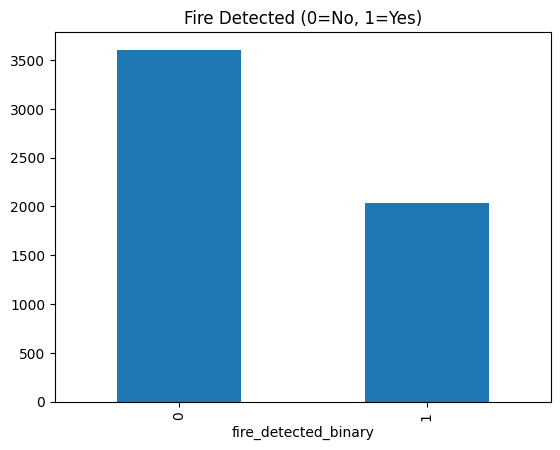

In [23]:
# Cell 3 — Target Variable
print("Target distribution:")
print(df["fire_detected_binary"].value_counts())
print(f"\nFire rate: {df['fire_detected_binary'].mean()*100:.2f}%")
df["fire_detected_binary"].value_counts().plot(kind="bar", title="Fire Detected (0=No, 1=Yes)")
plt.show()

In [24]:
# Cell 4 — Full Processing Pipeline

# Step 1: Fix sentinels & parse timestamp
df.replace(-9999, np.nan, inplace=True)
df["canopy_cover_pct"] = df["canopy_cover_pct"].where(df["canopy_cover_pct"] >= 0, np.nan)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["grid_id", "timestamp"]).reset_index(drop=True)

# Step 2: Forward-fill time-series cols by grid cell (before dropping grid_id)
ts_cols = ["cumulative_wind_run_24h", "drought_index_proxy"]
df[ts_cols] = df.groupby("grid_id")[ts_cols].ffill().bfill()

# Step 3: Drop constant, ID, leakage, and low-value columns
drop_cols = [
    "grid_id", "region", "data_quality_flag", "date",
    "resolution_km",
    "active_fire_count", "mean_frp", "median_frp",
    "max_confidence", "nearest_fire_distance_km",
    "days_since_last_precipitation",   # ablation showed ROC-AUC +0.0006 without it — capped at 1 day at inference anyway
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Step 4: Log1p transform right-skewed features
skewed_cols = ["precipitation", "vpd", "fire_weather_index", "soil_moisture_0_to_7cm"]
for col in skewed_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

# Step 5: Impute angular columns with median BEFORE circular encoding
for col in ["aspect_degrees", "wind_direction_10m"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Step 6: Circular encoding for angular features (avoids 0=360 discontinuity)
for col in ["wind_direction_10m", "aspect_degrees"]:
    df[f"{col}_sin"] = np.sin(np.radians(df[col]))
    df[f"{col}_cos"] = np.cos(np.radians(df[col]))
df.drop(columns=["wind_direction_10m", "aspect_degrees"], inplace=True)

# Step 7: Drop canopy_cover_pct if mostly null after sentinel cleanup
if "canopy_cover_pct" in df.columns and df["canopy_cover_pct"].isnull().mean() > 0.5:
    df.drop(columns=["canopy_cover_pct"], inplace=True)
    print("Dropped canopy_cover_pct (>50% null after sentinel cleanup)")

# Step 8: Cast to category dtype (LightGBM handles natively)
df["vegetation_type"] = df["vegetation_type"].astype("category")
df["fuel_model_fbfm40"] = df["fuel_model_fbfm40"].astype("category")

print("Shape after processing:", df.shape)
print("\nDate range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("\nRemaining null % (before imputation):")
null_pct = df.isnull().mean().sort_values(ascending=False)
print(null_pct[null_pct > 0].round(3))

Dropped canopy_cover_pct (>50% null after sentinel cleanup)
Shape after processing: (5635, 23)

Date range: 2024-06-01 00:00:00+00:00 to 2025-01-31 00:00:00+00:00

Remaining null % (before imputation):
ndvi                      0.261
slope_degrees             0.217
elevation_m               0.217
vegetation_type           0.174
dominant_fuel_fraction    0.174
fuel_model_fbfm40         0.174
dtype: float64


In [25]:
# Cell 5 — Imputation (static geography nulls only — angular cols already clean from Cell 4)
static_num = ["ndvi", "elevation_m", "slope_degrees", "dominant_fuel_fraction"]
for col in static_num:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Categorical: fill with mode
for col in ["fuel_model_fbfm40", "vegetation_type"]:
    df[col] = df[col].fillna(df[col].mode()[0])

remaining = df.isnull().sum().sum()
print(f"Nulls remaining after imputation: {remaining}")
assert remaining == 0, f"Still have {remaining} nulls — check columns above"

print("\nAll columns after full processing:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:<42s} [{df[col].dtype}]")

Nulls remaining after imputation: 0

All columns after full processing:
   1. latitude                                   [float64]
   2. longitude                                  [float64]
   3. timestamp                                  [datetime64[ns, UTC]]
   4. temperature_2m                             [float64]
   5. relative_humidity_2m                       [float64]
   6. wind_speed_10m                             [float64]
   7. precipitation                              [float64]
   8. soil_moisture_0_to_7cm                     [float64]
   9. vpd                                        [float64]
  10. fire_weather_index                         [float64]
  11. fuel_model_fbfm40                          [category]
  12. vegetation_type                            [category]
  13. ndvi                                       [float64]
  14. elevation_m                                [float64]
  15. slope_degrees                              [float64]
  16. fire_detected_binary   

In [26]:
# Cell 6 — Scaling (StandardScaler)
# Note: NOT needed for LightGBM (tree-based, scale-invariant)
# Use df_scaled only for sklearn/distance-based models
from sklearn.preprocessing import StandardScaler

scale_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "fire_detected_binary"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print(f"Scaled {len(scale_cols)} numeric features:")
for c in scale_cols:
    print(f"  {c}")
df_scaled[scale_cols].describe().round(2)

Scaled 19 numeric features:
  latitude
  longitude
  temperature_2m
  relative_humidity_2m
  wind_speed_10m
  precipitation
  soil_moisture_0_to_7cm
  vpd
  fire_weather_index
  ndvi
  elevation_m
  slope_degrees
  cumulative_wind_run_24h
  drought_index_proxy
  dominant_fuel_fraction
  wind_direction_10m_sin
  wind_direction_10m_cos
  aspect_degrees_sin
  aspect_degrees_cos


,latitude,longitude,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,soil_moisture_0_to_7cm,vpd,fire_weather_index,ndvi,elevation_m,slope_degrees,cumulative_wind_run_24h,drought_index_proxy,dominant_fuel_fraction,wind_direction_10m_sin,wind_direction_10m_cos,aspect_degrees_sin,aspect_degrees_cos
count,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00,5635.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.69,-1.75,-3.35,-2.07,-1.41,-0.43,-0.74,-1.22,-2.09,-1.18,-1.30,-1.74,-1.38,-3.35,-2.08,-1.20,-1.77,-1.09,-1.60
25%,-0.81,-0.93,-0.39,-0.95,-0.76,-0.43,-0.74,-0.80,-0.55,-0.77,-0.95,-0.54,-0.74,-0.29,-0.59,-0.79,-0.99,-0.98,-0.70
50%,0.01,-0.07,0.06,0.26,-0.40,-0.43,-0.52,-0.44,0.11,-0.46,-0.20,0.07,-0.40,0.44,-0.10,-0.24,0.50,-0.15,-0.26
75%,0.90,0.82,0.44,0.93,0.62,-0.19,0.44,0.74,0.74,0.54,0.83,0.72,0.61,0.60,0.50,0.49,0.89,0.75,1.13
max,1.73,1.72,2.47,1.48,3.90,5.57,3.06,2.90,2.33,2.31,1.84,2.62,3.96,1.40,2.54,2.50,1.02,2.69,1.17


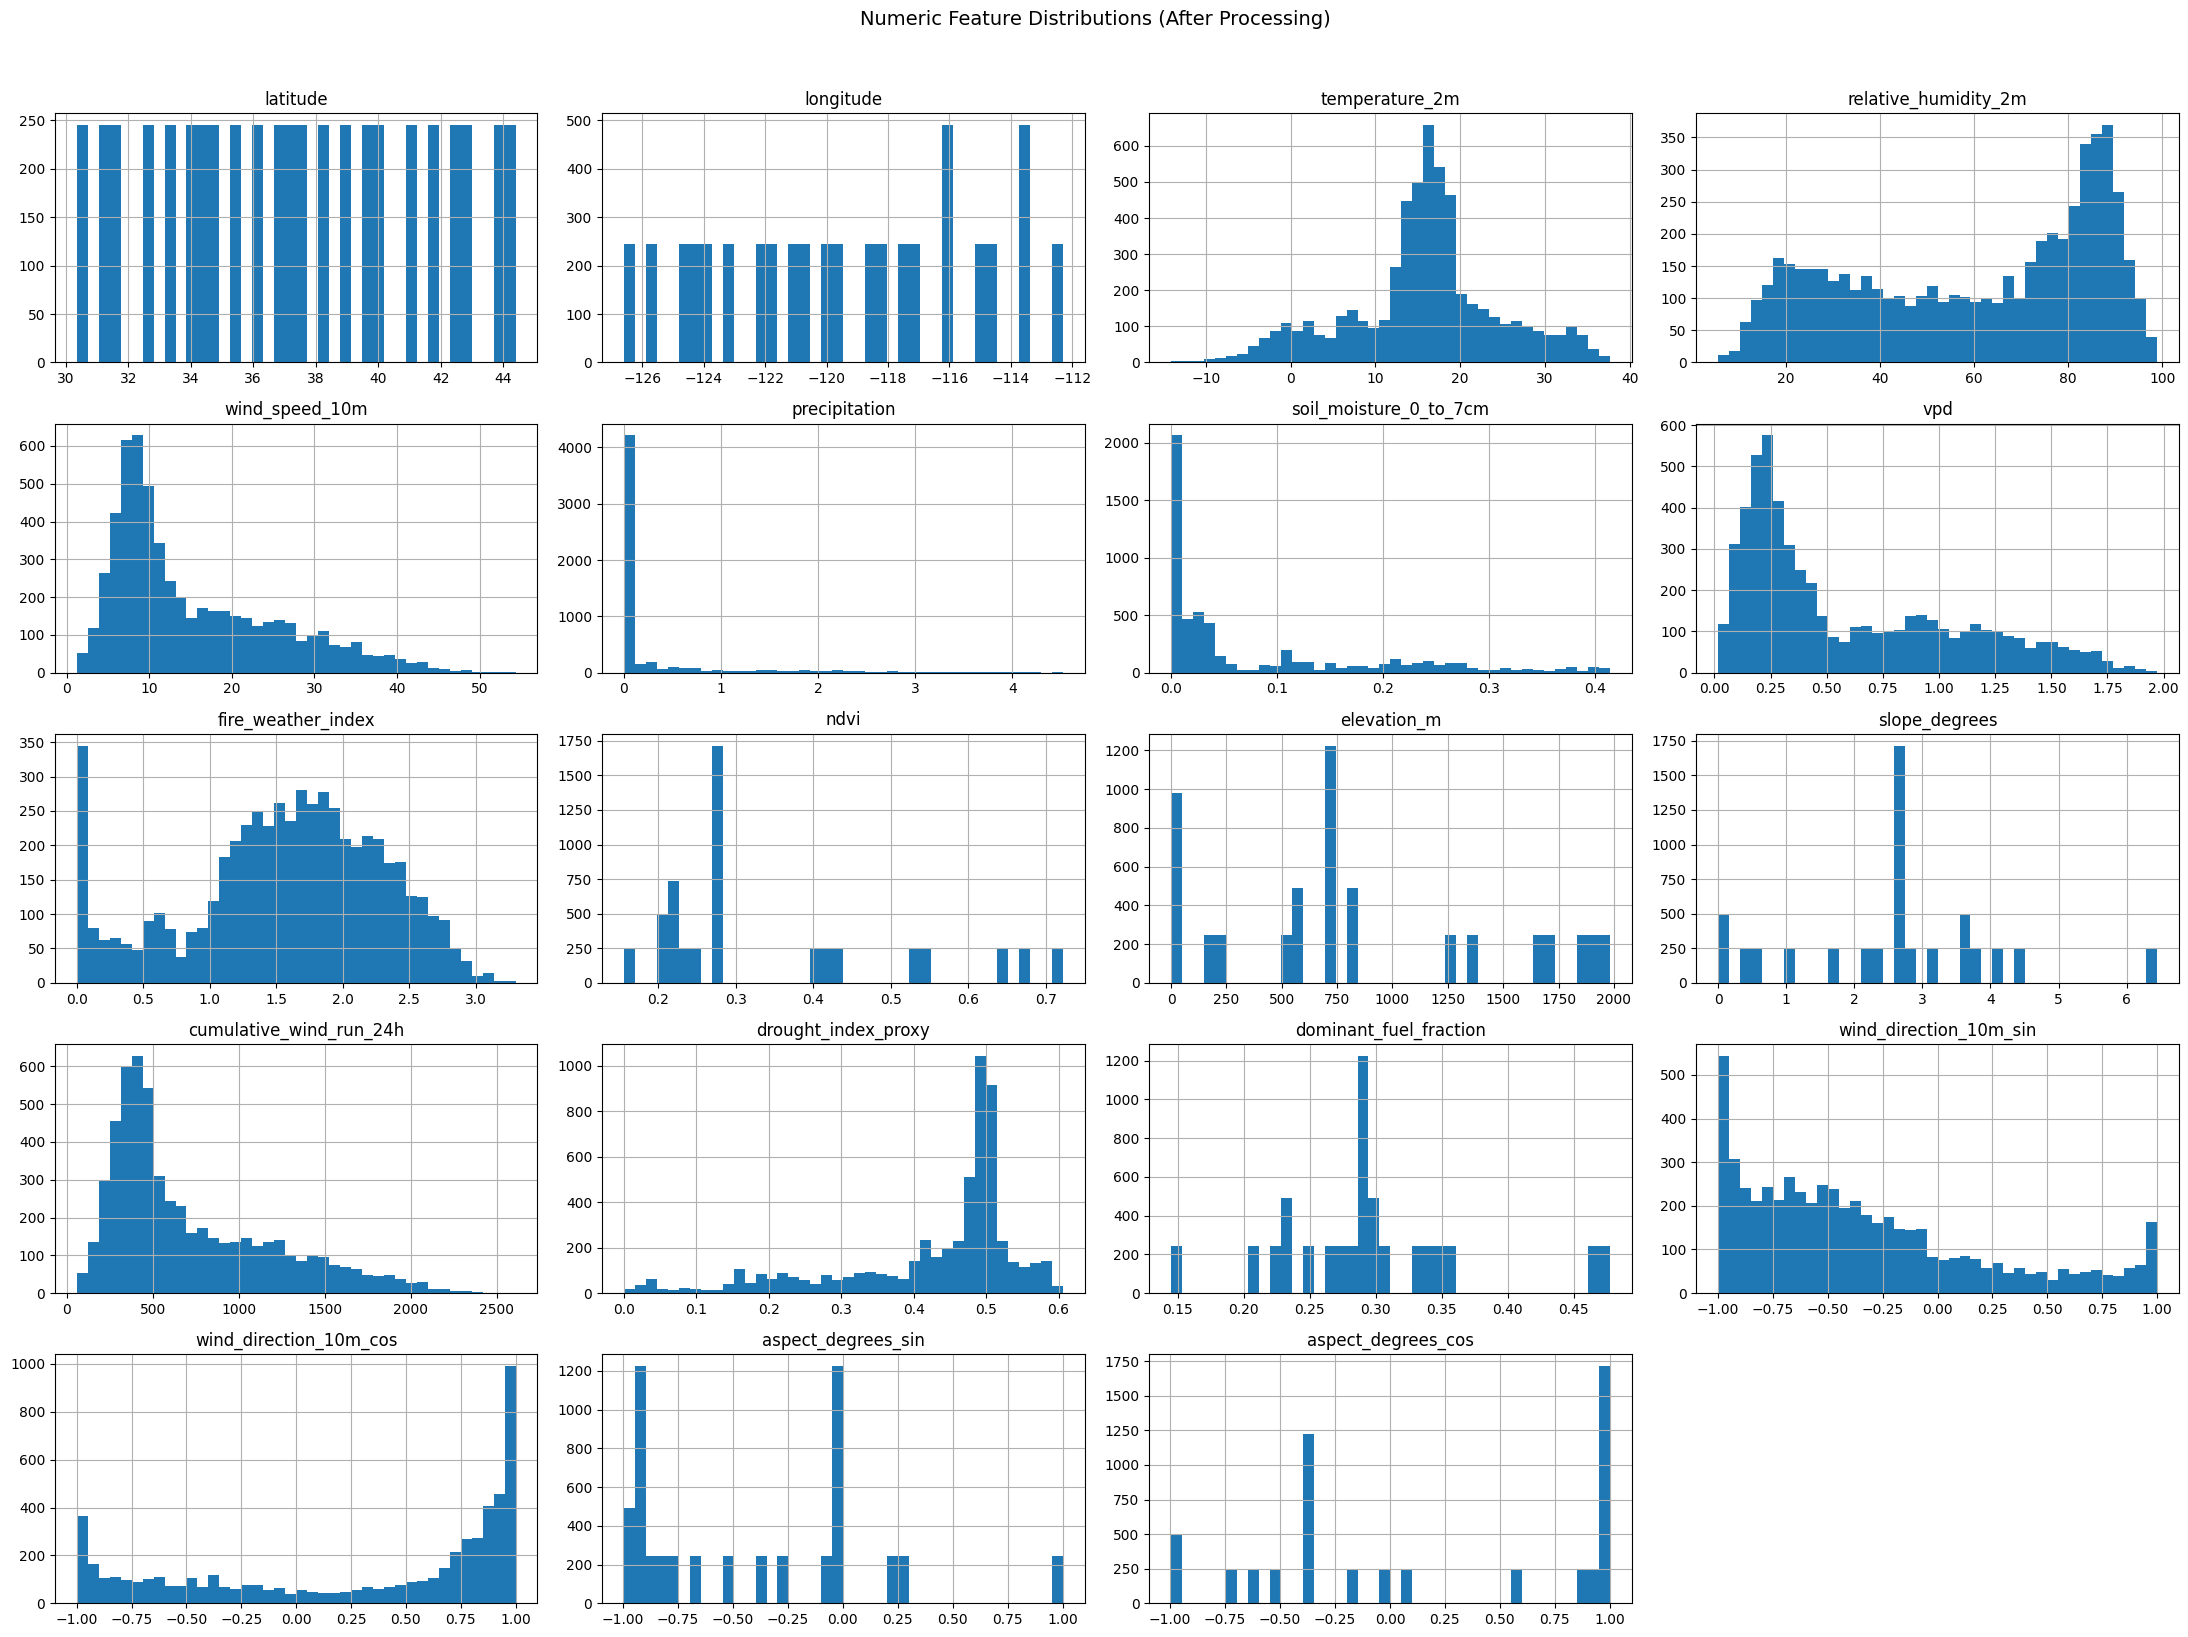

In [27]:
# Cell 7 — Post-Processing Numeric Distributions
num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "fire_detected_binary"
]
df[num_cols].hist(figsize=(22, 16), bins=40)
plt.suptitle("Numeric Feature Distributions (After Processing)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Feature correlation with fire_detected_binary (after processing):
vpd                        0.4087
relative_humidity_2m       0.3807
dominant_fuel_fraction     0.3246
cumulative_wind_run_24h    0.3139
wind_speed_10m             0.3063
slope_degrees              0.2428
temperature_2m             0.2304
fire_weather_index         0.1919
wind_direction_10m_sin     0.1757
precipitation              0.1474
longitude                  0.1386
elevation_m                0.1283
wind_direction_10m_cos     0.1128
aspect_degrees_cos         0.1044
soil_moisture_0_to_7cm     0.0719
drought_index_proxy        0.0382
aspect_degrees_sin         0.0092
ndvi                       0.0083
latitude                   0.0025


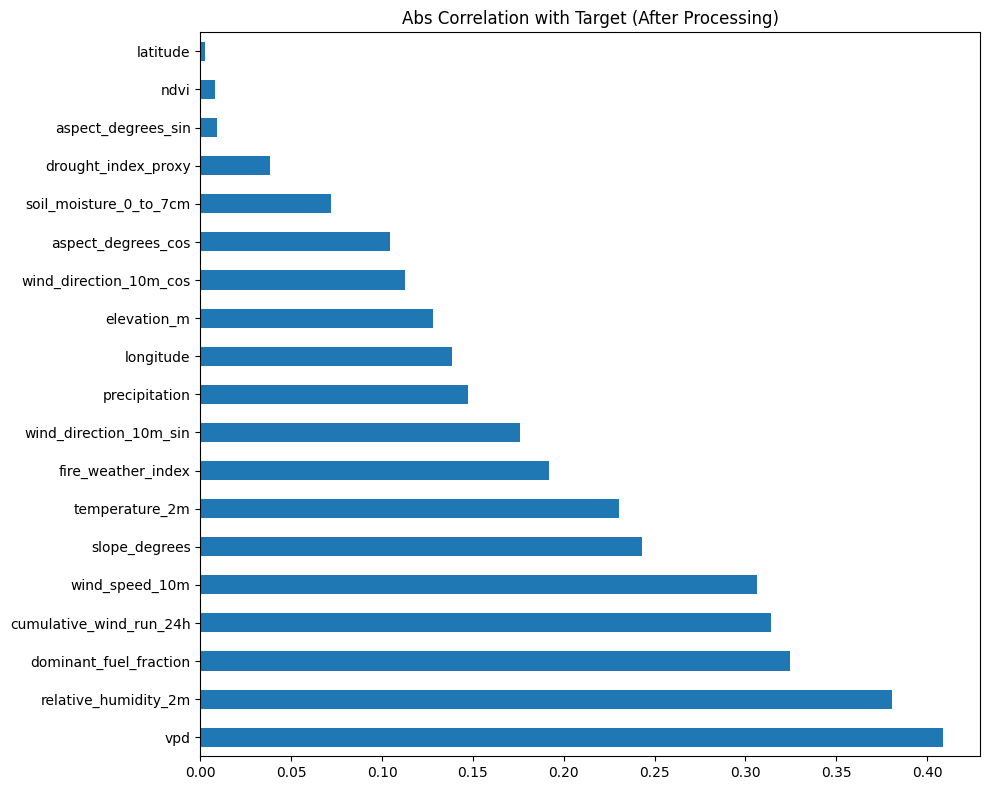

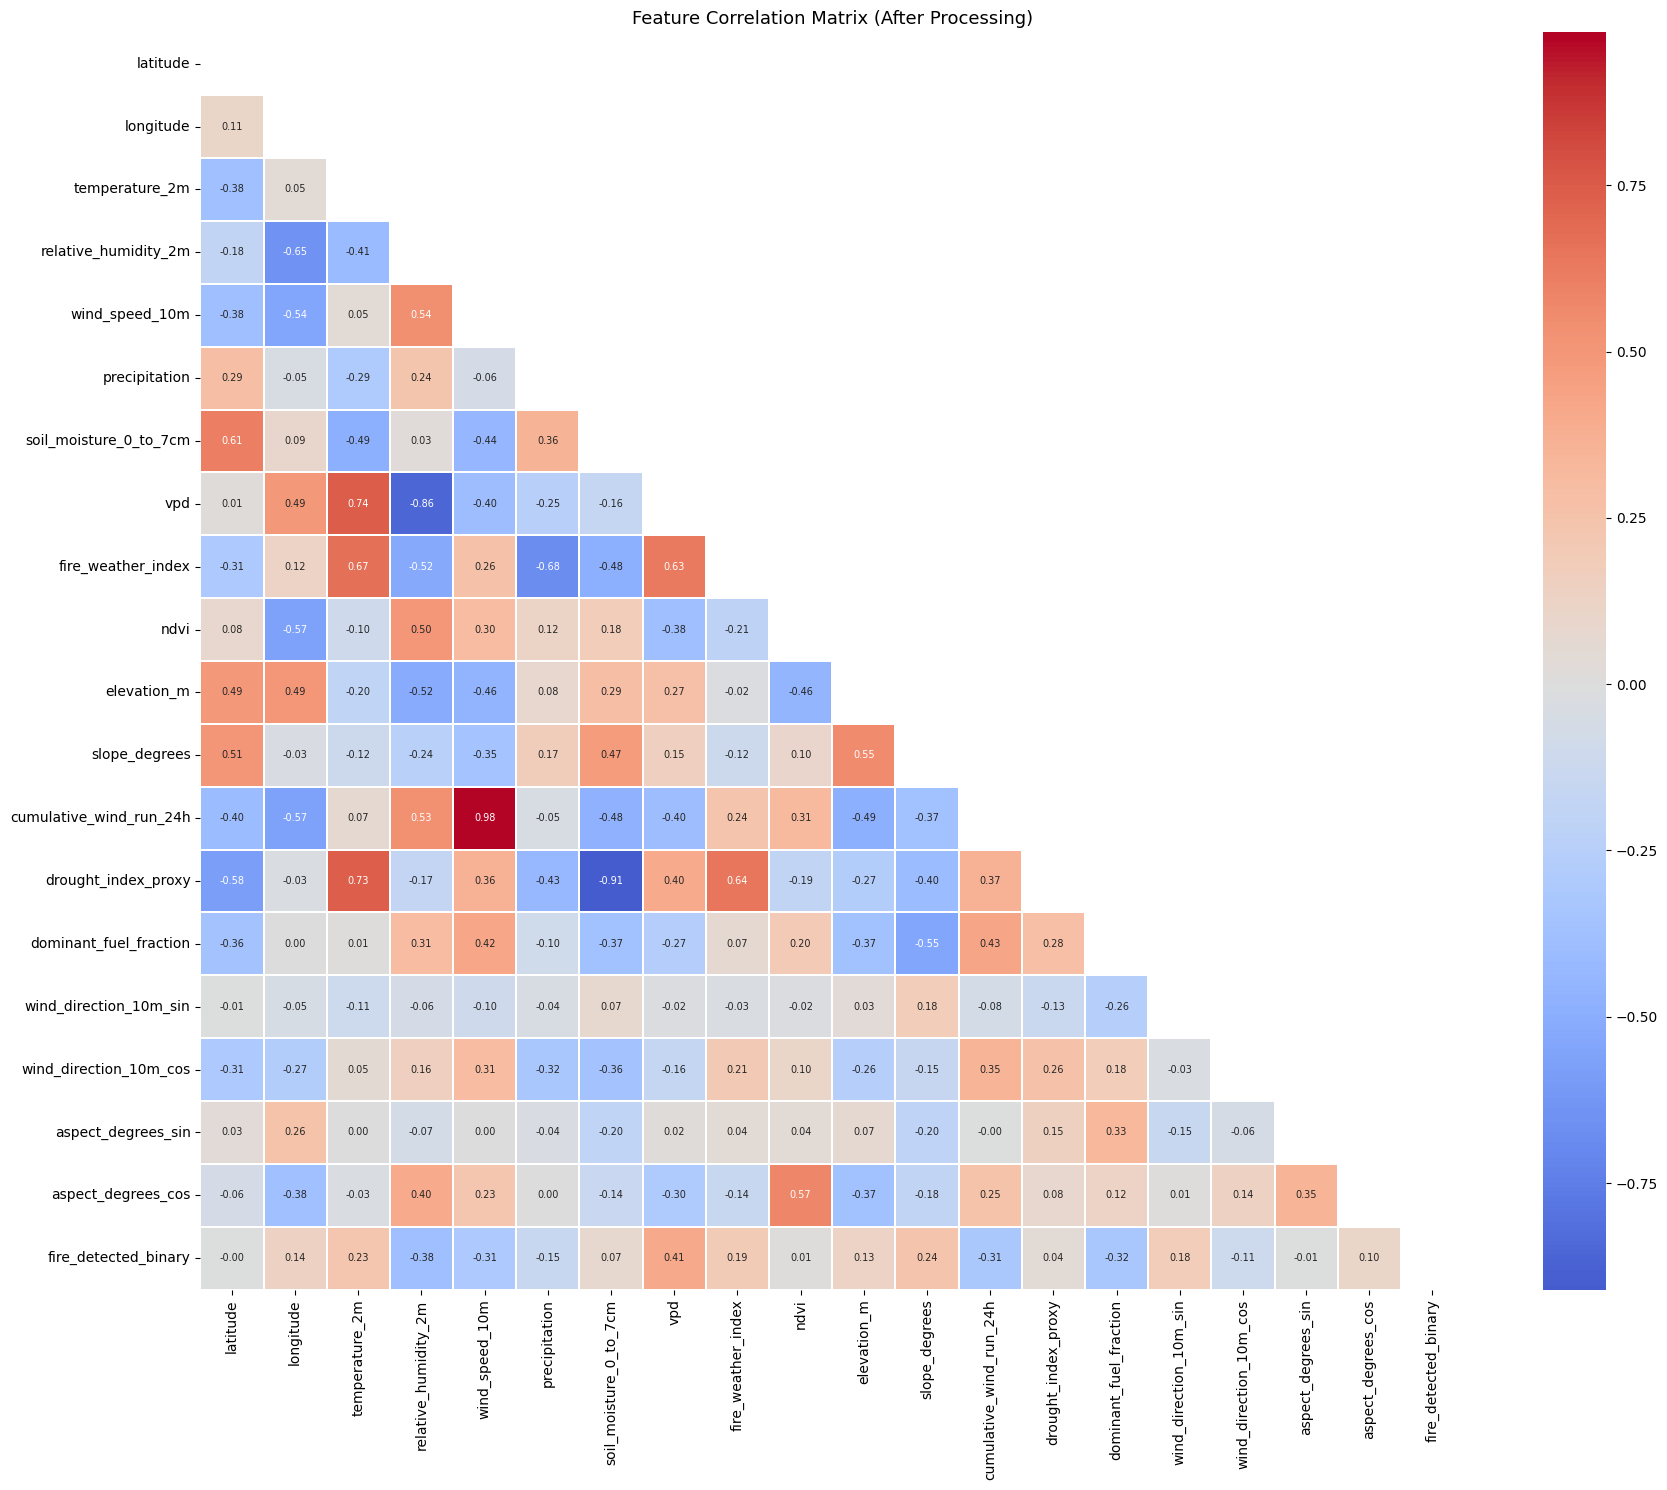

In [28]:
# Cell 8 — Correlation with Target + Heatmap
num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "fire_detected_binary"
]

corr = df[num_cols + ["fire_detected_binary"]].corr()["fire_detected_binary"].drop("fire_detected_binary")
corr_sorted = corr.abs().sort_values(ascending=False)

print("Feature correlation with fire_detected_binary (after processing):")
print(corr_sorted.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 8))
corr_sorted.plot(kind="barh", ax=ax, title="Abs Correlation with Target (After Processing)")
plt.tight_layout()
plt.show()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
corr_matrix = df[num_cols + ["fire_detected_binary"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.3,
    annot_kws={"size": 7}, ax=ax
)
ax.set_title("Feature Correlation Matrix (After Processing)", fontsize=13)
plt.tight_layout()
plt.show()

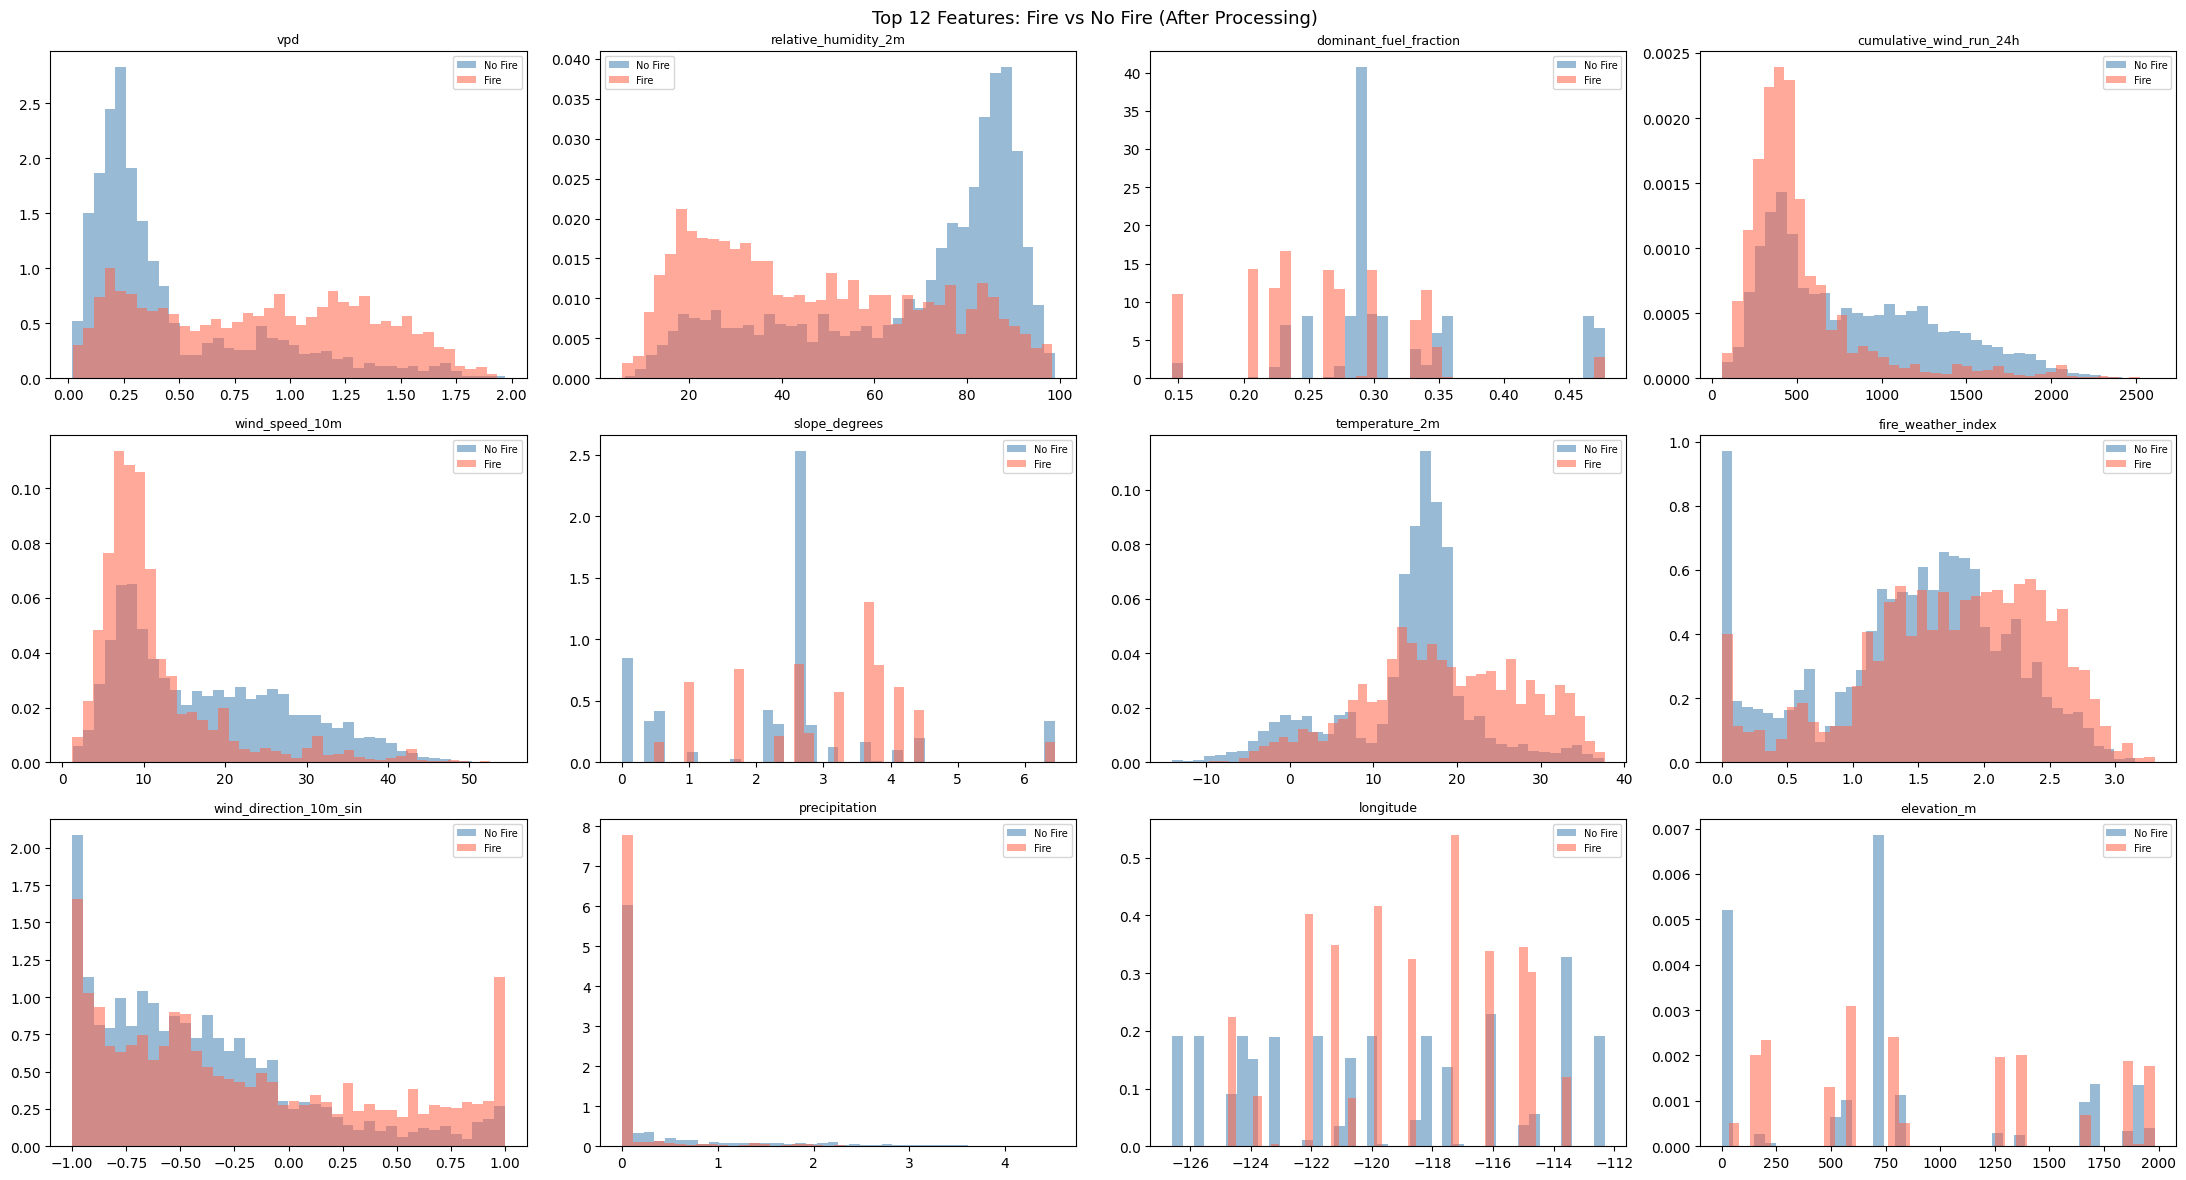

In [29]:
# Cell 9 — Fire vs No-Fire Distributions (Top 12 Features)
fire = df[df["fire_detected_binary"] == 1]
no_fire = df[df["fire_detected_binary"] == 0]

num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "fire_detected_binary"
]
corr = df[num_cols + ["fire_detected_binary"]].corr()["fire_detected_binary"].drop("fire_detected_binary")
top_features = corr.abs().sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(22, 12))
for ax, col in zip(axes.flatten(), top_features):
    ax.hist(no_fire[col].dropna(), bins=40, alpha=0.55, label="No Fire", density=True, color="steelblue")
    ax.hist(fire[col].dropna(), bins=40, alpha=0.55, label="Fire", density=True, color="tomato")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Top 12 Features: Fire vs No Fire (After Processing)", fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# Cell 10 — Temporal Split Check
df["year"] = df["timestamp"].dt.year
print("Rows per year:")
print(df.groupby("year")["fire_detected_binary"].agg(["count", "sum", "mean"]).round(4))

cutoff = pd.Timestamp("2025-01-01", tz="UTC")
train = df[df["timestamp"] < cutoff].copy()
test  = df[df["timestamp"] >= cutoff].copy()
print(f"\nTrain: {len(train)} rows, fire rate: {train['fire_detected_binary'].mean()*100:.2f}%")
print(f"Test:  {len(test)} rows,  fire rate: {test['fire_detected_binary'].mean()*100:.2f}%")

Rows per year:
      count   sum    mean
year                     
2024   4922  1790  0.3637
2025    713   240  0.3366

Train: 4922 rows, fire rate: 36.37%
Test:  713 rows,  fire rate: 33.66%


In [31]:
# Cell 11 — LightGBM Baseline
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

feature_cols = [
    c for c in df.columns
    if c not in ["fire_detected_binary", "timestamp", "year"]
]
X_train = train[feature_cols]
X_test  = test[feature_cols]
y_train = train["fire_detected_binary"]
y_test  = test["fire_detected_binary"]

# LightGBM handles NaN and category dtype natively
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows | Features: {len(feature_cols)}")

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC (avg prec): {average_precision_score(y_test, y_prob):.4f}")
print(classification_report(y_test, (y_prob > 0.5).astype(int)))

scale_pos_weight: 1.7
Train: 4922 rows | Test: 713 rows | Features: 21

ROC-AUC:           0.9381
PR-AUC (avg prec): 0.8879
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       473
           1       0.79      0.78      0.79       240

    accuracy                           0.86       713
   macro avg       0.84      0.84      0.84       713
weighted avg       0.86      0.86      0.86       713



=== Threshold = 0.3 ===
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       473
           1       0.76      0.81      0.78       240

    accuracy                           0.85       713
   macro avg       0.83      0.84      0.83       713
weighted avg       0.85      0.85      0.85       713

First threshold with recall >= 0.90:  threshold=0.000  precision=0.337  recall=1.000


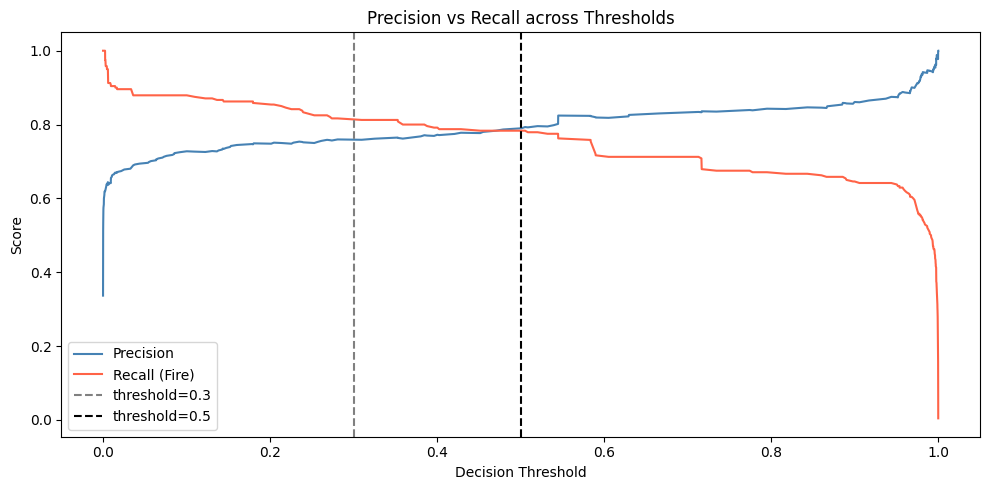

In [32]:
# Cell 12 — Threshold Analysis
from sklearn.metrics import precision_recall_curve, classification_report

# Results at threshold 0.3
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)
print(f"=== Threshold = {threshold} ===")
print(classification_report(y_test, y_pred_03))

# Sweep thresholds to find where recall >= 0.90
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
for t, p, r in zip(thresholds, prec[:-1], rec[:-1]):
    if r >= 0.90:
        print(f"First threshold with recall >= 0.90:  threshold={t:.3f}  precision={p:.3f}  recall={r:.3f}")
        break

# Plot precision-recall tradeoff across thresholds
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, rec[:-1], label="Recall (Fire)", color="tomato")
ax.axvline(0.3, color="gray", linestyle="--", label="threshold=0.3")
ax.axvline(0.5, color="black", linestyle="--", label="threshold=0.5")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision vs Recall across Thresholds")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Cell 16 — XGBoost: Data Format Check & Encoding
from sklearn.preprocessing import OrdinalEncoder

print("=== Data Format Check for XGBoost ===\n")

# Check 1: category dtypes — XGBoost cannot handle, needs int encoding
cat_cols = X_train.select_dtypes(include="category").columns.tolist()
print(f"Category dtype columns (need encoding): {cat_cols}")

# Check 2: NaN values — XGBoost 1.6+ handles natively
null_counts = X_train.isnull().sum()
print(f"\nNaN counts in X_train:")
print(null_counts[null_counts > 0].to_string() if null_counts.any() else "  None")

# Check 3: non-numeric dtypes
non_numeric = X_train.select_dtypes(exclude=[np.number, "category"]).columns.tolist()
print(f"\nNon-numeric, non-category columns (must be empty): {non_numeric}")

# Fix: OrdinalEncoder for category columns
# Fit on train only, transform both — prevents data leakage
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()

if cat_cols:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train_xgb[cat_cols] = enc.fit_transform(X_train_xgb[cat_cols].astype(str))
    X_test_xgb[cat_cols]  = enc.transform(X_test_xgb[cat_cols].astype(str))
    print(f"\nEncoded {cat_cols} → integer codes")

# Verify all dtypes are now numeric
print("\nFinal dtypes (all should be numeric):")
print(X_train_xgb.dtypes.value_counts().to_string())
print("\nData is ready for XGBoost ✓" if X_train_xgb.select_dtypes(exclude=np.number).empty else "⚠ Non-numeric columns remain")

=== Data Format Check for XGBoost ===

Category dtype columns (need encoding): ['fuel_model_fbfm40', 'vegetation_type']

NaN counts in X_train:
  None

Non-numeric, non-category columns (must be empty): []

Encoded ['fuel_model_fbfm40', 'vegetation_type'] → integer codes

Final dtypes (all should be numeric):
float64    21

Data is ready for XGBoost ✓


In [34]:
# Cell 17 — XGBoost RandomizedSearchCV
import xgboost as xgb
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

xgb_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {xgb_scale_pos_weight:.1f}")

param_dist_xgb = {
    "n_estimators":      randint(200, 1000),
    "learning_rate":     uniform(0.01, 0.2),
    "max_depth":         randint(3, 10),
    "min_child_weight":  randint(1, 20),
    "subsample":         uniform(0.5, 0.5),
    "colsample_bytree":  uniform(0.5, 0.5),
    "reg_alpha":         uniform(0.0, 1.0),
    "reg_lambda":        uniform(0.0, 2.0),
    "gamma":             uniform(0.0, 0.5),
}

base_xgb = xgb.XGBClassifier(
    scale_pos_weight=xgb_scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric="auc",
    early_stopping_rounds=None,
)

search_xgb = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_xgb.fit(X_train_xgb, y_train)

print(f"\nBest ROC-AUC (CV): {search_xgb.best_score_:.4f}")
print("Best params:")
for k, v in search_xgb.best_params_.items():
    print(f"  {k}: {v}")

scale_pos_weight: 1.7
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best ROC-AUC (CV): 0.7147
Best params:
  colsample_bytree: 0.7044764722071349
  gamma: 0.08664716003542289
  learning_rate: 0.04128740853421721
  max_depth: 4
  min_child_weight: 16
  n_estimators: 800
  reg_alpha: 0.6601973767177313
  reg_lambda: 0.5598677938918857
  subsample: 0.977432640331597


LightGBM ROC-AUC (tuned): 0.9380
XGBoost  ROC-AUC (tuned): 0.9426
XGBoost  PR-AUC:          0.8927

Threshold for recall >= 0.9: 0.365
  Precision: 0.725  |  Recall: 0.900

=== Classification Report at threshold=0.365 ===
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       473
           1       0.72      0.90      0.80       240

    accuracy                           0.85       713
   macro avg       0.83      0.86      0.84       713
weighted avg       0.87      0.85      0.85       713



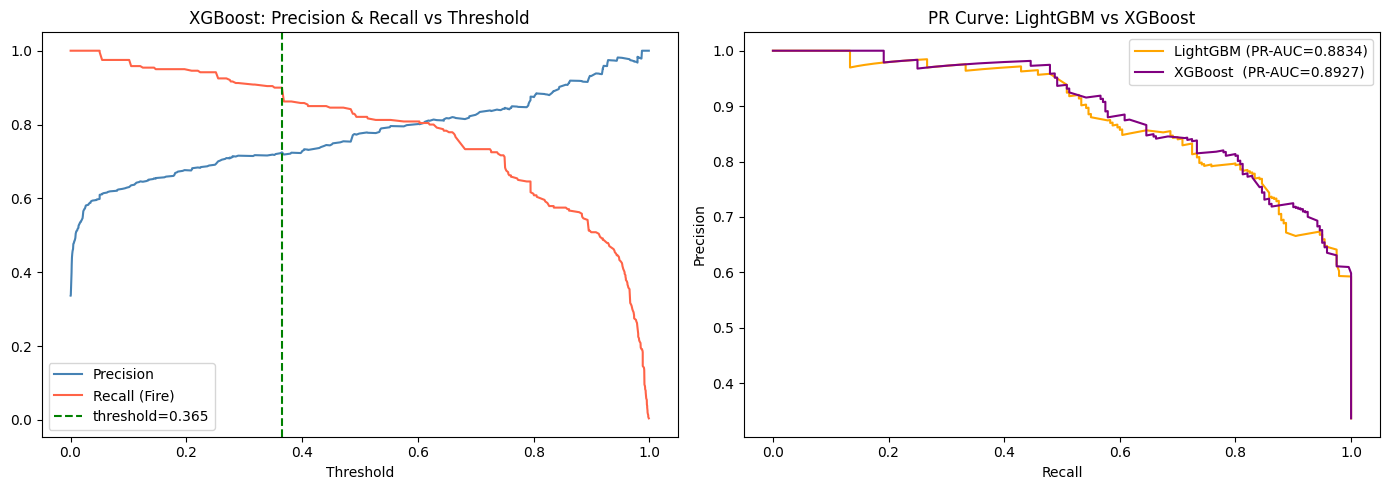

In [35]:
# Cell 18 — XGBoost: Evaluate on Test Set + Threshold Tuning
best_xgb = search_xgb.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

roc_lgbm = roc_auc_score(y_test, y_prob_best)
roc_xgb  = roc_auc_score(y_test, y_prob_xgb)
pr_xgb   = average_precision_score(y_test, y_prob_xgb)

print(f"LightGBM ROC-AUC (tuned): {roc_lgbm:.4f}")
print(f"XGBoost  ROC-AUC (tuned): {roc_xgb:.4f}")
print(f"XGBoost  PR-AUC:          {pr_xgb:.4f}")

# Threshold tuning — same logic as LightGBM
prec_xgb, rec_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)
target_recall = 0.90
candidates_xgb = np.where(rec_xgb[:-1] >= target_recall)[0]

if len(candidates_xgb) == 0:
    print(f"\nXGBoost cannot reach recall={target_recall} at any threshold.")
else:
    idx_xgb = candidates_xgb[-1]
    best_threshold_xgb = thresholds_xgb[idx_xgb]
    print(f"\nThreshold for recall >= {target_recall}: {best_threshold_xgb:.3f}")
    print(f"  Precision: {prec_xgb[idx_xgb]:.3f}  |  Recall: {rec_xgb[idx_xgb]:.3f}")
    print(f"\n=== Classification Report at threshold={best_threshold_xgb:.3f} ===")
    print(classification_report(y_test, (y_prob_xgb >= best_threshold_xgb).astype(int)))

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: precision-recall vs threshold
axes[0].plot(thresholds_xgb, prec_xgb[:-1], label="Precision", color="steelblue")
axes[0].plot(thresholds_xgb, rec_xgb[:-1],  label="Recall (Fire)", color="tomato")
if len(candidates_xgb):
    axes[0].axvline(best_threshold_xgb, color="green", linestyle="--", label=f"threshold={best_threshold_xgb:.3f}")
axes[0].set_title("XGBoost: Precision & Recall vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].legend()

# Right: PR curves LightGBM vs XGBoost
prec_lgbm, rec_lgbm, _ = precision_recall_curve(y_test, y_prob_best)
axes[1].plot(rec_lgbm, prec_lgbm, label=f"LightGBM (PR-AUC={average_precision_score(y_test, y_prob_best):.4f})", color="orange")
axes[1].plot(rec_xgb,  prec_xgb,  label=f"XGBoost  (PR-AUC={pr_xgb:.4f})", color="purple")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve: LightGBM vs XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Cell 13 — Hyperparameter Search (RandomizedSearchCV, optimize ROC-AUC)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

param_dist = {
    "n_estimators":      randint(200, 1000),
    "learning_rate":     uniform(0.01, 0.2),
    "num_leaves":        randint(20, 150),
    "max_depth":         randint(3, 12),
    "min_child_samples": randint(10, 100),
    "subsample":         uniform(0.5, 0.5),    # samples 0.5–1.0
    "colsample_bytree":  uniform(0.5, 0.5),    # features 0.5–1.0
    "reg_alpha":         uniform(0.0, 1.0),    # L1
    "reg_lambda":        uniform(0.0, 1.0),    # L2
}

base_clf = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# TimeSeriesSplit respects temporal order — no future leakage during CV
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest ROC-AUC (CV): {search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best ROC-AUC (CV): 0.7459
Best params:
  colsample_bytree: 0.8035171238433423
  learning_rate: 0.06519983640450867
  max_depth: 3
  min_child_samples: 98
  n_estimators: 720
  num_leaves: 107
  reg_alpha: 0.3948815181755697
  reg_lambda: 0.2934881747180381
  subsample: 0.5070399113575422


Baseline ROC-AUC (default params): 0.9372
Tuned   ROC-AUC (best params):     0.9380
Tuned   PR-AUC:                    0.8834

Threshold for recall >= 0.9: 0.243
  Precision at that threshold:  0.666
  Recall at that threshold:     0.904

=== Classification Report at threshold=0.243 ===
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       473
           1       0.67      0.90      0.77       240

    accuracy                           0.81       713
   macro avg       0.80      0.84      0.81       713
weighted avg       0.85      0.81      0.82       713

Threshold = 0.25
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       473
           1       0.68      0.89      0.77       240

    accuracy                           0.82       713
   macro avg       0.80      0.84      0.81       713
weighted avg       0.85      0.82      0.82       713

Threshold = 0.275
              precision

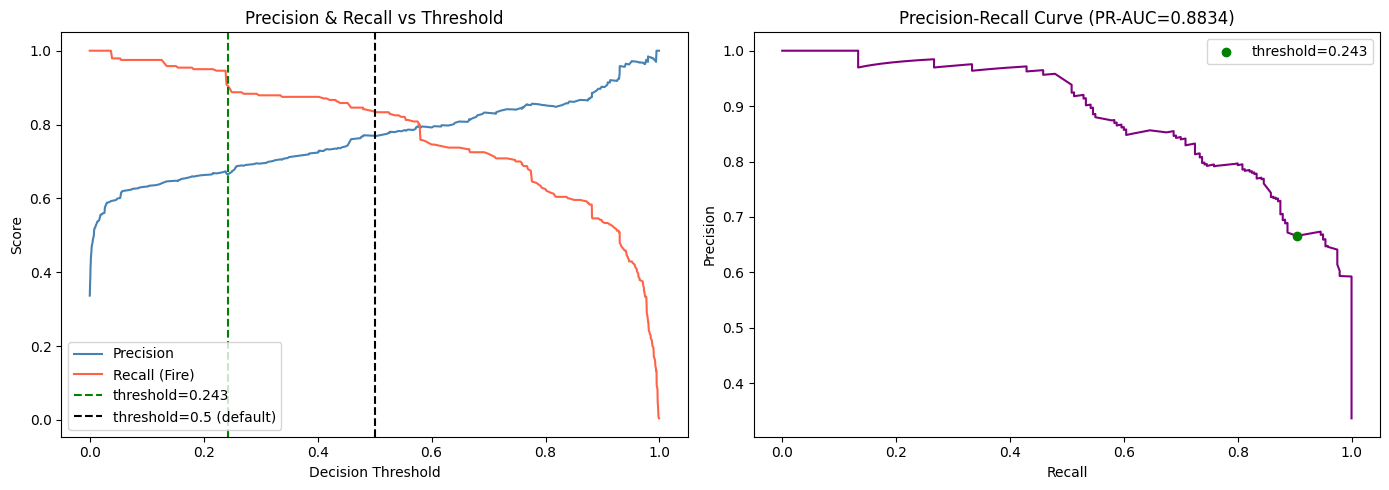

In [37]:
# Cell 14 — Evaluate Best Model on Test Set + Threshold Tuning
best_clf = search.best_estimator_
y_prob_best = best_clf.predict_proba(X_test)[:, 1]

print(f"Baseline ROC-AUC (default params): 0.9372")
print(f"Tuned   ROC-AUC (best params):     {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"Tuned   PR-AUC:                    {average_precision_score(y_test, y_prob_best):.4f}")

# precision_recall_curve returns recall in DESCENDING order
# We want the highest threshold that still achieves recall >= target
prec, rec, thresholds = precision_recall_curve(y_test, y_prob_best)
target_recall = 0.90
candidates = np.where(rec[:-1] >= target_recall)[0]  # exclude last point (no threshold)
if len(candidates) == 0:
    print(f"\nModel cannot reach recall={target_recall} at any threshold.")
else:
    idx = candidates[-1]  # last = highest threshold achieving target recall
    best_threshold = thresholds[idx]
    print(f"\nThreshold for recall >= {target_recall}: {best_threshold:.3f}")
    print(f"  Precision at that threshold:  {prec[idx]:.3f}")
    print(f"  Recall at that threshold:     {rec[idx]:.3f}")
    print(f"\n=== Classification Report at threshold={best_threshold:.3f} ===")
    print(classification_report(y_test, (y_prob_best >= best_threshold).astype(int)))

    for t in [0.25, 0.275, 0.3, 0.35]:
        print(f"{'='*45}")
        print(f"Threshold = {t}")
        print(classification_report(y_test, (y_prob_best >= t).astype(int)))

# Plot full precision-recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: threshold sweep
axes[0].plot(thresholds, prec[:-1], label="Precision", color="steelblue")
axes[0].plot(thresholds, rec[:-1], label="Recall (Fire)", color="tomato")
if len(candidates):
    axes[0].axvline(best_threshold, color="green", linestyle="--", label=f"threshold={best_threshold:.3f}")
axes[0].axvline(0.5, color="black", linestyle="--", label="threshold=0.5 (default)")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision & Recall vs Threshold")
axes[0].legend()

# Right: PR curve
axes[1].plot(rec, prec, color="purple")
if len(candidates):
    axes[1].scatter(rec[idx], prec[idx], color="green", zorder=5, label=f"threshold={best_threshold:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (PR-AUC={average_precision_score(y_test, y_prob_best):.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()

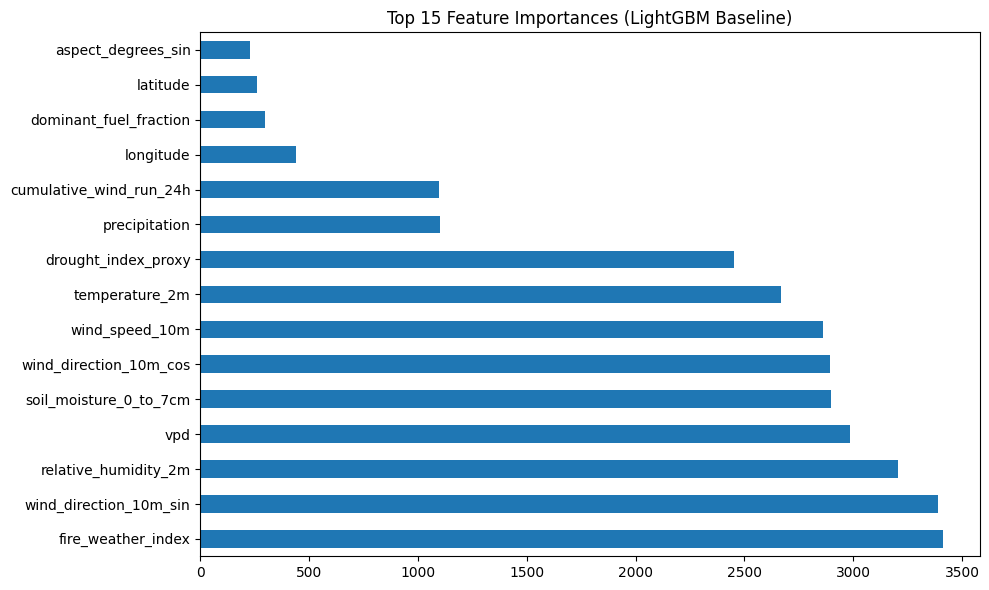

fire_weather_index               3412
wind_direction_10m_sin           3390
relative_humidity_2m             3205
vpd                              2985
soil_moisture_0_to_7cm           2896
wind_direction_10m_cos           2892
wind_speed_10m                   2863
temperature_2m                   2667
drought_index_proxy              2453
precipitation                    1103
cumulative_wind_run_24h          1096
longitude                         441
dominant_fuel_fraction            295
latitude                          262
aspect_degrees_sin                229
slope_degrees                     205
aspect_degrees_cos                152
fuel_model_fbfm40                 116
elevation_m                       113
ndvi                              104
vegetation_type                    62
days_since_last_precipitation      59


In [ ]:
# Cell 12 — Feature Importance
feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feat_imp.head(15).plot(kind="barh", figsize=(10, 6), title="Top 15 Feature Importances (LightGBM Baseline)")
plt.tight_layout()
plt.show()
print(feat_imp.to_string())